Dada a base CIFAR10 que contém imagens organizadas em 10 classes, considere a criação de um classificador.

Estratégia a serem avaliadas:

1) treinamento e avaliação de uma CNN criada do zero;

In [8]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

In [4]:
# 1. Verificando a presença da GPU
print("Buscando dispositivos físicos (GPU)...")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"Sucesso! GPU(s) encontrada(s): {gpus}")
else:
    print("Nenhuma GPU encontrada. Verifique as configurações do Colab.")

# 2. Carregando e pré-processando a base CIFAR-10
print("Carregando os dados...")
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Normalizando os pixels para o intervalo [0, 1]
train_images = train_images.astype('float32') / 255.0
test_images = test_images.astype('float32') / 255.0

# Transformando os rótulos em vetores categóricos (one-hot encoding)
train_labels = to_categorical(train_labels, 10)
test_labels = to_categorical(test_labels, 10)

# 3. Forçando a construção e treinamento do modelo na GPU 0
print("Construindo o modelo na GPU...")
model = models.Sequential()

# Camadas Convolucionais
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))

# Camadas Densas
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

# Compilação
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Treinamento
print("Iniciando o treinamento (agora muito mais rápido!)...")
history = model.fit(train_images, train_labels, 
                    epochs=15, 
                    validation_split=0.2,
                    batch_size=64)

# Avaliação Final
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f"\nAcurácia final no conjunto de teste: {test_acc*100:.2f}%")

Buscando dispositivos físicos (GPU)...
Sucesso! GPU(s) encontrada(s): [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Carregando os dados...
Construindo o modelo na GPU...
Iniciando o treinamento (agora muito mais rápido!)...


W0000 00:00:1782679016.276306   96108 cpu_allocator_impl.cc:82] Allocation of 491520000 exceeds 10% of free system memory.


Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.4134 - loss: 1.5885 - val_accuracy: 0.5313 - val_loss: 1.3128
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5667 - loss: 1.2203 - val_accuracy: 0.6061 - val_loss: 1.1156
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6262 - loss: 1.0626 - val_accuracy: 0.6280 - val_loss: 1.0544
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6632 - loss: 0.9635 - val_accuracy: 0.6606 - val_loss: 0.9635
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.6895 - loss: 0.8876 - val_accuracy: 0.6745 - val_loss: 0.9277
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7142 - loss: 0.8236 - val_accuracy: 0.6825 - val_loss: 0.9179
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7359 - loss: 0.7679 - val_accuracy: 0.6862 - val_loss: 0.9123
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7522 - loss: 0.7234 - val_accuracy: 0

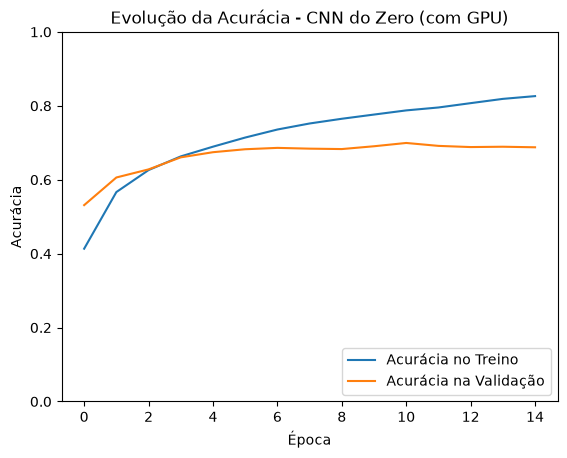

In [5]:
plt.plot(history.history['accuracy'], label='Acurácia no Treino')
plt.plot(history.history['val_accuracy'], label='Acurácia na Validação')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.title('Evolução da Acurácia - CNN do Zero (com GPU)')
plt.show()

In [9]:
y_pred_prob = model.predict(test_images)
y_pred_classes = np.argmax(y_pred_prob, axis=1)
y_true_classes = np.argmax(test_labels, axis=1)

cm = confusion_matrix(y_true_classes, y_pred_classes)
print("Matriz de Confusão:")
print(cm)

print("\nRelatório de Classificação:")
print(classification_report(y_true_classes, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Matriz de Confusão:
[[723  18  32  29  25  13   9  21  78  52]
 [ 25 729   4  15  11  10  12   6  23 165]
 [ 69  11 512 101 108  79  49  40  13  18]
 [ 18   9  46 578  85 157  35  35  10  27]
 [ 22   3  67  86 651  39  26  88  11   7]
 [ 11   3  51 210  40 578  20  60  12  15]
 [  3   4  68 114  69  24 686  16   4  12]
 [ 16   3  28  50  55  52   6 767   4  19]
 [ 72  38   9  25   9  11   7   3 766  60]
 [ 29  45   8  20   7  14   5  16  19 837]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.73      0.72      0.73      1000
           1       0.84      0.73      0.78      1000
           2       0.62      0.51      0.56      1000
           3       0.47      0.58      0.52      1000
           4       0.61      0.65      0.63      1000
           5       0.59      0.58      0.58      1000
           6       0.80      0.69      0.74      1000
           7       0.73      0.77      0.75   